# --------------------------*Rice leaf Prediction using CNN*-----------------------------


# *Step 1: Import libraries*

* **os** — a Python standard library used for interacting with the operating system, such as accessing files, folders, and directory paths.

* **cv2 (OpenCV)** — an open-source computer vision library used for reading, resizing, processing, and manipulating images.

* **PIL.Image** — a Python imaging library used to open, display, verify, and perform basic operations on image files.

* **numpy** — a Python library for fast numerical computing, arrays, and mathematical operations.

* **pandas** — a Python library for working with structured/tabular data using DataFrames and Series.

* **matplotlib.pyplot** — a Python plotting library for creating static charts, graphs, and displaying images.

* **seaborn** — a statistical data visualization library built on top of matplotlib that creates attractive and informative plots.

* **train_test_split** — a function that randomly splits the dataset into training and testing subsets for model training and evaluation.

* **confusion_matrix** — a function that generates a matrix showing the number of correct and incorrect predictions made by the classification model.

* **classification_report** — a function that generates a report containing Precision, Recall, F1-score, and Support for each class.

* **accuracy_score** — a metric that calculates the proportion of correctly classified samples out of the total number of samples.

* **tensorflow** — an open-source deep learning framework used to build, train, and deploy neural network models.

* **Sequential** — a Keras model that allows neural network layers to be added one after another in sequence.

* **Conv2D** — a convolutional layer used in CNNs to automatically extract important features such as edges, textures, and patterns from images.

* **MaxPooling2D** — a pooling layer that reduces the size of feature maps while retaining the most important information, helping reduce computation and overfitting.

* **Flatten** — a layer that converts multi-dimensional feature maps into a one-dimensional vector before passing them to fully connected layers.

* **Dense** — a fully connected neural network layer where each neuron is connected to every neuron in the previous layer for classification.

* **Dropout** — a regularization layer that randomly deactivates neurons during training to reduce overfitting and improve model generalization.

* **BatchNormalization** — a layer that normalizes the outputs of previous layers, making training faster, more stable, and improving convergence.

* **GlobalAveragePooling2D** — a pooling layer that computes the average value of each feature map, reducing the number of parameters and helping prevent overfitting.

* **Input** — a layer used to define the input shape of images before they are passed through the neural network.

* **ImageDataGenerator** — a preprocessing utility that performs data augmentation by applying transformations such as rotation, zoom, shifting, and flipping to training images.

* **to_categorical** — a utility function that converts integer class labels into one-hot encoded vectors for multi-class classification.

* **warnings.filterwarnings("ignore")** — a function that suppresses Python warning messages, keeping the notebook output clean and easier to read.


In [1]:
# For working with files and folders
import os

# For image processing
import cv2
from PIL import Image

# For numerical operations
import numpy as np

# For data manipulation
import pandas as pd

# For displaying images and graphs
import matplotlib.pyplot as plt

# For plotting statistical graphs
import seaborn as sns

# For splitting the dataset
from sklearn.model_selection import train_test_split

# For performance evaluation
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score
)

# TensorFlow & Keras for Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization, 
    GlobalAveragePooling2D, 
    Input
)

# For Image Data Augmentation
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# For converting labels into numbers
from tensorflow.keras.utils import to_categorical

# To ignore warning messages
import warnings
warnings.filterwarnings("ignore")

# Step 2: Loading the Dataset



### 2.1: Define Dataset Path
- **dataset_path** is a variable used to store the location of the Rice Leaf Disease dataset.
- **r (Raw String)** tells Python to treat backslashes (\) as normal characters, allowing Windows file paths to be interpreted correctly.
- **"D:\datamites projects\PRCP-1001-RiceLeaf\Data"** is the complete path to the folder containing all the rice leaf disease images.
- This path is later used to access, read, and preprocess the images for training and testing the CNN model.

In [2]:
dataset_path = r"D:\datamites projects\PRCP-1001-RiceLeaf\Data"

### 2.2: Check Whether the Path Exists
- **os.path.exists()** is a function that checks whether the specified file or folder path exists.
- **dataset_path** is passed as an argument to verify if the dataset folder is available at the given location.
- If the path exists, the function returns True; otherwise, it returns False.
- This step ensures that the dataset is available before loading the images, helping avoid file path errors during execution.

In [3]:
print(os.path.exists(dataset_path))

True


#### 2.3: **Display the Contents of the Dataset**
- **os.listdir(dataset_path)** returns a list of all files and folders present inside the dataset directory.
- **for folder in ...** loops through each folder in the dataset one by one.
- **print(folder)** displays the name of each folder, which represents a rice leaf disease class.
- This step helps verify that all disease folders are present and can be accessed before loading the images.

In [4]:
for folder in os.listdir(dataset_path):
    print(folder)

Bacterial leaf blight-20200814T055237Z-001
Brown spot-20200814T055208Z-001
Leaf smut-20200814T055530Z-001


### 2.6: Create Empty Lists
- We need one list for the image data and one list for the corresponding labels
- **images** → Stores all image data.
- **labels** → Stores the corresponding disease label. 

In [5]:
images = []
labels = []

### 2.7: Create Label Dictionary
- **label_dict** is a Python dictionary used to assign a unique numerical label to each rice leaf disease class.
- The dictionary maps folder names to integer values,
- where:
       - Bacterial Leaf Blight → 0
       - Brown Spot → 1
       - Leaf Smut → 2
 - Numerical labels are used because machine learning and CNN models work with numbers instead of text labels.
 - print(label_dict) displays the dictionary to verify that each disease class has been assigned the correct label.

In [6]:
label_dict = {
    "Bacterial leaf blight-20200814T055237Z-001": 0,
    "Brown spot-20200814T055208Z-001": 1,
    "Leaf smut-20200814T055530Z-001": 2
}
print(label_dict)

{'Bacterial leaf blight-20200814T055237Z-001': 0, 'Brown spot-20200814T055208Z-001': 1, 'Leaf smut-20200814T055530Z-001': 2}


In [7]:
import os

dataset_path = r"D:\datamites projects\PRCP-1001-RiceLeaf\Data"

print("Path Exists:", os.path.exists(dataset_path))
print("Dataset Path:", dataset_path)
print("Contents:", os.listdir(dataset_path))

Path Exists: True
Dataset Path: D:\datamites projects\PRCP-1001-RiceLeaf\Data
Contents: ['Bacterial leaf blight-20200814T055237Z-001', 'Brown spot-20200814T055208Z-001', 'Leaf smut-20200814T055530Z-001']


# Step 3:Read Images

- **IMG_SIZE** is a variable used to define the size (height and width) to which all images will be resized.
- **224** means each image will be resized to 224 × 224 pixels before being passed to the CNN model.
- Resizing all images to the same dimensions ensures consistency, as CNN models require every input image to have the same size.
- The value 224 is commonly used in deep learning models (such as VGG16, ResNet, and MobileNet) because it provides a good balance between image quality and computational efficiency.

In [8]:
IMG_SIZE = 224

- The nested for loops traverse the dataset folders and access every rice leaf image by moving through the main folder, disease folders, and individual image files.
- Each image is opened using Image.open(), converted to RGB format, and resized to 224 × 224 pixels to ensure all images have the same dimensions for CNN training.
- The processed image is converted into a NumPy array and stored in the images list, making it ready for further preprocessing and model training.
- The corresponding numerical label is retrieved from label_dict and stored in the labels list, ensuring that every image is associated with the correct disease class.
- Finally, len(images) and len(labels) are printed to verify that all images have been loaded successfully and that each image has a corresponding label.

In [9]:
for outer_folder in os.listdir(dataset_path):

    outer_path = os.path.join(dataset_path, outer_folder)

    for disease_folder in os.listdir(outer_path):

        disease_path = os.path.join(outer_path, disease_folder)

        for image_name in os.listdir(disease_path):

            image_path = os.path.join(disease_path, image_name)

            img = Image.open(image_path).convert("RGB")
            img = img.resize((IMG_SIZE, IMG_SIZE))

            images.append(np.array(img))
            labels.append(label_dict[outer_folder])  

print("Total Images :", len(images))
print("Total Labels :", len(labels))

Total Images : 119
Total Labels : 119


- type() is a built-in Python function used to determine the data type of a variable.
- print(type(images)) displays the data type of the images variable.
- print(type(labels)) displays the data type of the labels variable.
- Before converting them to NumPy arrays, both images and labels are stored as Python lists because images and labels are added using the append() method.
- This step verifies that the data has been stored correctly before converting it into NumPy arrays for CNN model training.

In [10]:
print(type(images))
print(type(labels))

<class 'list'>
<class 'list'>


### 3.1 **Convert them to NumPy arrays**
- **np.array()** is a NumPy function used to convert Python lists into NumPy arrays.
- **images** = np.array(images) converts the list of image data into a NumPy array for efficient processing.
- **labels** = np.array(labels) converts the list of numerical labels into a NumPy array.
- NumPy arrays provide faster computation, require less memory, and are optimized for mathematical operations, making them suitable for deep learning.
- TensorFlow/Keras models require input data in the form of NumPy arrays, so this conversion is essential before preprocessing and training the CNN model.

In [11]:
import numpy as np

images = np.array(images)
labels = np.array(labels)

In [12]:
print(type(images))
print(type(labels))

print(images.shape)
print(labels.shape)

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
(119, 224, 224, 3)
(119,)


## Step 4: Exploratory Data Analysis(EDA)

- Exploratory Data Analysis (EDA) is the process of exploring and understanding the dataset before training the machine learning model.
- EDA helps identify important information such as the number of images, class distribution, image size, data types, and any missing or corrupted data.
- Visualizations such as sample images, bar charts, pie charts, and count plots are used to understand the characteristics of the dataset.
- The insights gained from EDA help in preprocessing the data correctly, ensuring better model performance and reducing errors during training.

### 4.1: **Check the Data Type of Images and Labels**
- .dtype is a NumPy attribute used to check the data type of the elements stored in an array.
- images.dtype displays the data type of the image pixel values (for example, uint8 before normalization).
- labels.dtype displays the data type of the class labels (for example, int64 or int32).
- Checking the data types ensures that the images and labels are stored in the correct format before preprocessing and model training.
- Correct data types improve computational efficiency and help prevent errors during CNN model training.

In [13]:
print("Image Data Type :", images.dtype)
print("Label Data Type :", labels.dtype)

Image Data Type : uint8
Label Data Type : int64


### 4.2: **Check Unique Class Labels**
- np.unique() is a NumPy function that returns all the unique values present in an array.
- labels contains the numerical labels assigned to each rice leaf disease image.
- This function displays all the unique class labels, helping verify that all disease classes are present in the dataset.
- It confirms that the labels have been assigned correctly and that there are no unexpected or duplicate class values.
- This step ensures the dataset is ready for training, with each disease represented by a unique numerical label.

In [14]:
print("Unique Labels :", np.unique(labels))

Unique Labels : [0 1 2]


### 4.3: **Count Images in Each Class**
- This step counts the total number of images available in each rice leaf disease class.
- It helps determine whether the dataset is balanced or imbalanced by comparing the number of images in each class.
- A balanced dataset improves the CNN model's learning, as each disease class is represented equally during training.
- The image count is usually obtained using functions such as np.unique(labels, return_counts=True) or Counter(labels), which calculate the frequency of each class label.
- This analysis ensures that all disease classes have sufficient images before proceeding with model training.

In [15]:
unique, counts = np.unique(labels, return_counts=True)

for label, count in zip(unique, counts):
    print(f"Class {label} : {count} images")

Class 0 : 40 images
Class 1 : 40 images
Class 2 : 39 images


### 4.4: Visualize Class Distribution Using a Bar Chart
- class_names stores the names of the three rice leaf disease classes that will be displayed on the x-axis of the bar chart.
- plt.figure(figsize=(7,5)) creates a new figure with a width of 7 inches and a height of 5 inches for better visualization.
- plt.bar(class_names, counts) creates a bar chart where class_names are displayed on the x-axis and counts (number of images in each class) are displayed on the y-axis.
- plt.title(), plt.xlabel(), and plt.ylabel() add a chart title and labels to the x-axis and y-axis, making the graph easier to understand.
- plt.show() displays the completed bar chart, helping visualize the distribution of images across the three disease classes.

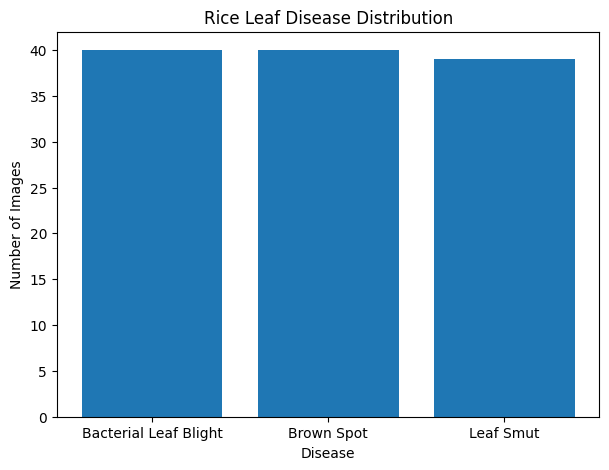

In [16]:
import matplotlib.pyplot as plt

class_names = [
    "Bacterial Leaf Blight",
    "Brown Spot",
    "Leaf Smut"
]

plt.figure(figsize=(7,5))

plt.bar(class_names, counts)

plt.title("Rice Leaf Disease Distribution")
plt.xlabel("Disease")
plt.ylabel("Number of Images")

plt.show()

### 4.5: **Visualize Disease Distribution Using a Pie Chart**
- plt.figure(figsize=(6,6)) creates a new figure with a size of 6 × 6 inches for displaying the pie chart.
- plt.pie() creates a pie chart using the image counts (counts) of each rice leaf disease class.
- labels=class_names, autopct="%1.1f%%", and startangle=90 display the disease names, show the percentage of each class with one decimal place, and rotate the chart to start from 90° for better visualization.
- plt.title("Disease Distribution") adds a title to the pie chart, making it easy to understand what the chart represents.
- plt.show() displays the completed pie chart, helping visualize the percentage distribution of images in each disease class.


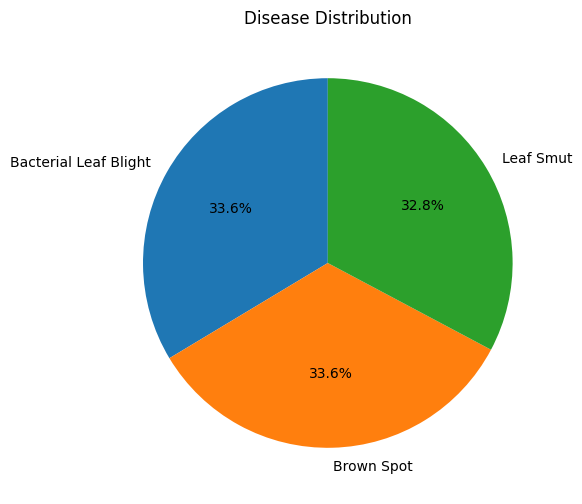

In [17]:
plt.figure(figsize=(6,6))

plt.pie(
    counts,
    labels=class_names,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Disease Distribution")

plt.show()

### 4.6: **Display Sample Images from Each Disease Class**
- class_names is a dictionary that maps each numerical label (0, 1, and 2) to its corresponding rice leaf disease name.
- for label in range(3) iterates through all three disease classes, allowing one sample image from each class to be displayed.
- np.where(labels == label)[0][0] finds the index of the first image belonging to the current disease class.
- plt.subplot(), plt.imshow(), plt.title(), and plt.axis("off") display each sample image with its disease name as the title and hide the axis for a cleaner visualization.
- plt.tight_layout() adjusts the spacing between the images, and plt.show() displays all three sample images in a single figure.

##### Importance:
- This code is used to display one sample image from each rice leaf disease class, helping us visually inspect the dataset.
- It verifies that the images are loaded correctly and that each numerical label is mapped to the correct disease class before training the CNN model.

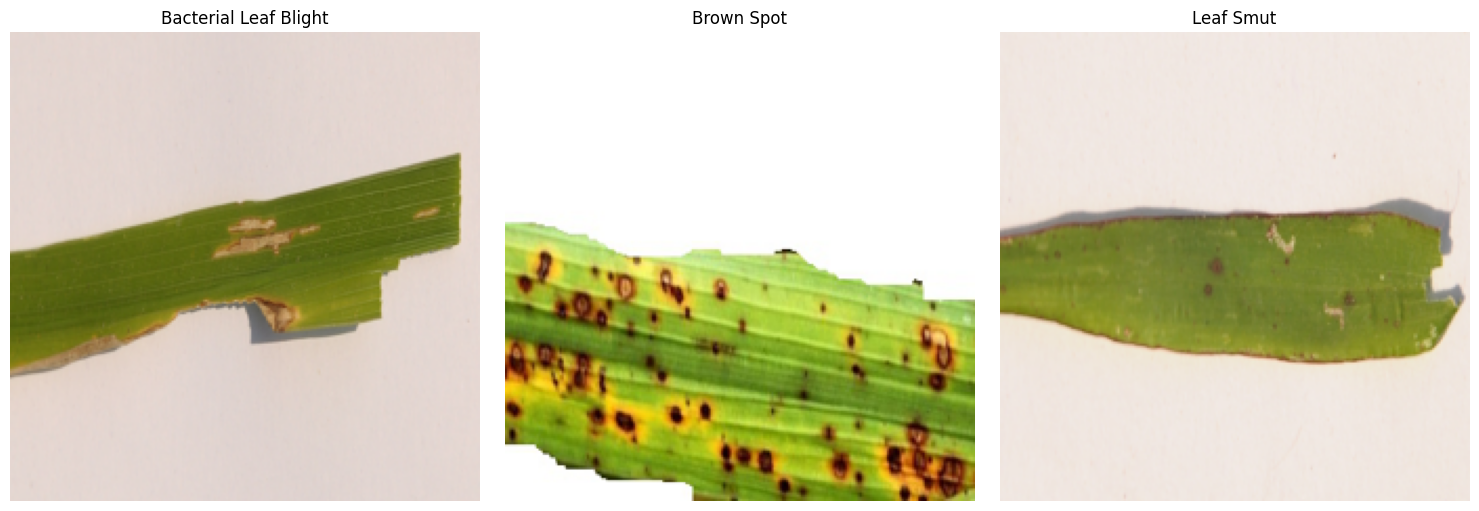

In [18]:
class_names = {
    0: "Bacterial Leaf Blight",
    1: "Brown Spot",
    2: "Leaf Smut"
}

plt.figure(figsize=(15,5))

for label in range(3):

    index = np.where(labels == label)[0][0]

    plt.subplot(1,3,label+1)
    plt.imshow(images[index])
    plt.title(class_names[label])
    plt.axis("off")

plt.tight_layout()
plt.show()

### 4.7: Display Random Sample Images 
- import random imports the random module, which is used to randomly select images from the dataset.
- plt.figure(figsize=(10,10)) creates a figure of size 10 × 10 inches to display multiple images.
- random.randint(0, len(images)-1) randomly selects an image index from the dataset.
- plt.subplot(), plt.imshow(), plt.title(), and plt.axis("off") display each randomly selected image with its corresponding label and hide the axis.
- plt.tight_layout() adjusts the spacing between images, and plt.show() displays the final 3 × 3 grid of random sample images.

##### Importance :
- This code displays random sample images from the dataset to visually inspect the image quality and diversity.
- It helps verify that the images and their corresponding labels have been loaded correctly before model training.

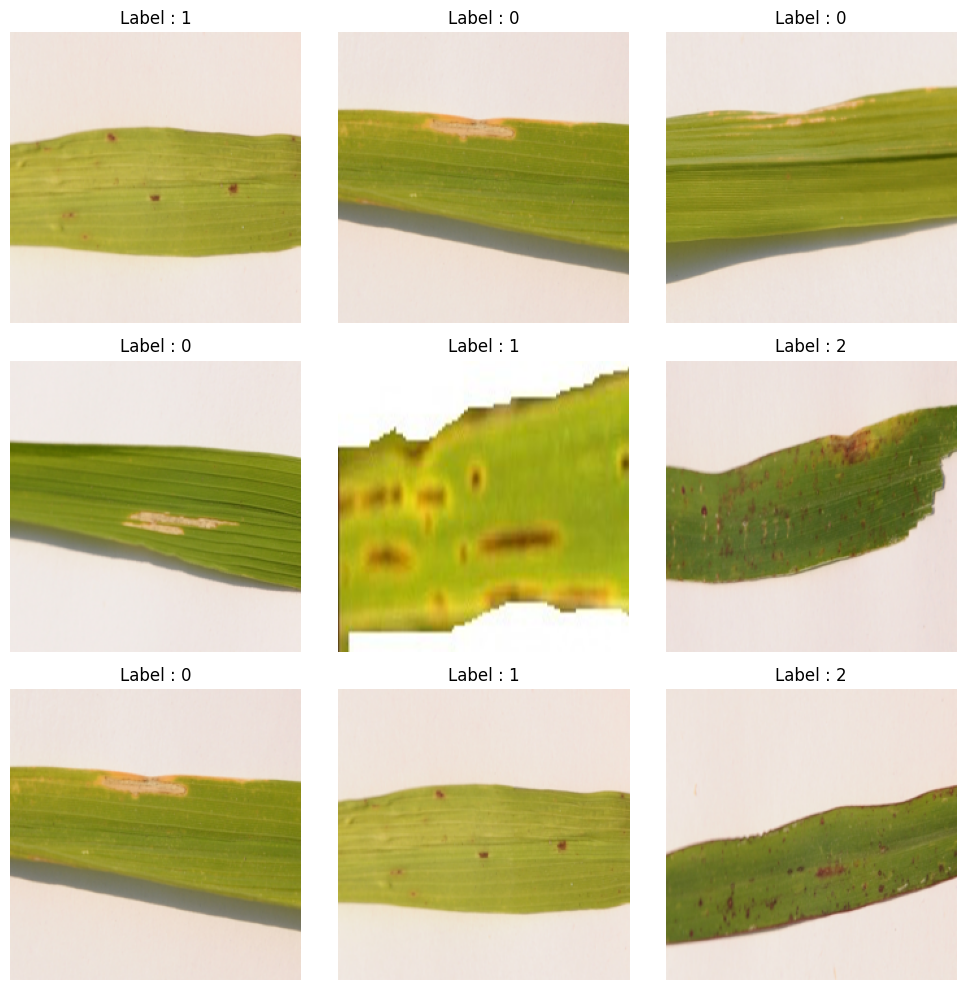

In [19]:
import random

plt.figure(figsize=(10,10))

for i in range(9):

    index = random.randint(0, len(images)-1)

    plt.subplot(3,3,i+1)

    plt.imshow(images[index])

    plt.title(f"Label : {labels[index]}")

    plt.axis("off")

plt.tight_layout()

plt.show()

### 4.8 **Check Image Dimensions**
- images.shape returns the dimensions (shape) of the image dataset.
- images.shape[1] displays the height of each image in pixels.
- images.shape[2] displays the width of each image in pixels.
- images.shape[3] displays the number of color channels, where 3 represents an RGB image (Red, Green, and Blue).
- This step verifies that all images have the same dimensions (224 × 224 × 3), which is required for training the CNN model.

##### Importance:
- This code is used to verify the dimensions of the images after preprocessing.
- It ensures that all images have a uniform size (224 × 224 × 3), which is required as input for the CNN model.

In [20]:
print("Height :", images.shape[1])
print("Width :", images.shape[2])
print("Channels :", images.shape[3])

Height : 224
Width : 224
Channels : 3


### 4.9: **Check the Pixel Value Range**
- images.min() returns the minimum pixel value present in the image dataset.
- images.max() returns the maximum pixel value present in the image dataset.
- For RGB images, pixel values typically range from 0 to 255, where 0 represents the darkest pixel and 255 represents the brightest pixel.
- This step verifies that the images have been loaded correctly and checks the pixel value range before normalization.
- Knowing the pixel value range helps prepare the images for preprocessing, such as scaling the values between 0 and 1 before training the CNN model.

##### Importance:
- This code checks the minimum and maximum pixel values in the image dataset.
- It ensures that the images have the expected pixel value range (0–255) before normalization and model training.

In [21]:
print("Minimum Pixel Value :", images.min())
print("Maximum Pixel Value :", images.max())

Minimum Pixel Value : 0
Maximum Pixel Value : 255


## Dataset Quality Check
##### 4.10: **Check for Missing Images**
- os.listdir() retrieves all disease folders and image files from the dataset directory.
- os.path.join() constructs the complete path for each disease folder and image file.
- os.path.exists() checks whether each image file exists at the specified path.
- If an image is missing, its path is printed and the missing_images counter is incremented to keep track of missing files.
- Finally, the total number of missing images is displayed, helping verify the completeness of the dataset before training the CNN model.

##### Importance:
- This code checks whether any image files are missing from the dataset.
- It ensures the dataset is complete and prevents file-related errors during CNN model training.

In [22]:
import os

missing_images = 0

for disease in os.listdir(dataset_path):

    disease_path = os.path.join(dataset_path, disease)

    if not os.path.isdir(disease_path):
        continue

    for image_name in os.listdir(disease_path):

        image_path = os.path.join(disease_path, image_name)

        if not os.path.exists(image_path):
            print("Missing:", image_path)
            missing_images += 1

print("Total Missing Images:", missing_images)

Total Missing Images: 0


### 4.11: **Check for Corrupted Images**
- os.listdir() and os.path.join() are used to traverse all dataset folders and create the complete path for each image file.
- image_name.lower().endswith((".jpg", ".jpeg", ".png")) ensures that only valid image files are checked.
- mage.open() opens each image, and img.verify() checks whether the image is valid or corrupted without fully loading it.
- If an image is corrupted, it is added to the corrupted_images list using the try-except block, which prevents the program from stopping due to errors.
- Finally, the total number of corrupted images and their file paths are displayed, helping identify and remove damaged images before training the CNN model.


In [23]:
from PIL import Image
import os

corrupted_images = []

for outer_folder in os.listdir(dataset_path):

    outer_path = os.path.join(dataset_path, outer_folder)

    if not os.path.isdir(outer_path):
        continue

    for disease_folder in os.listdir(outer_path):

        disease_path = os.path.join(outer_path, disease_folder)

        if not os.path.isdir(disease_path):
            continue

        for image_name in os.listdir(disease_path):

            if image_name.lower().endswith((".jpg", ".jpeg", ".png")):

                image_path = os.path.join(disease_path, image_name)

                try:
                    img = Image.open(image_path)
                    img.verify()

                except Exception:
                    corrupted_images.append(image_path)

print("Total Corrupted Images:", len(corrupted_images))

for img in corrupted_images:
    print(img)

Total Corrupted Images: 0


4.12: Count the Number of Images in Each Class
- np.unique(labels, return_counts=True) finds all unique class labels and counts the number of images in each class.
- unique stores the distinct class labels (e.g., 0, 1, and 2), while counts stores the corresponding number of images.
- zip(unique, counts) pairs each class label with its image count.
- The for loop iterates through each label-count pair and prints the number of images for each disease class.
- This step helps verify the class distribution and determines whether the dataset is balanced before training the CNN model.

##### Importance:
- This code counts the number of images in each disease class.
- It helps verify whether the dataset is balanced, which is important for accurate CNN model training.

In [24]:
unique, counts = np.unique(labels, return_counts=True)

for label, count in zip(unique, counts):
    print(f"Class {label}: {count} images")

Class 0: 40 images
Class 1: 40 images
Class 2: 39 images


## Step 5: Data Preprocessing

- Data preprocessing is the process of preparing the dataset before training the CNN model.
- It includes tasks such as normalizing pixel values, encoding labels, splitting the dataset, and applying data augmentation to improve model performance.
- Preprocessing ensures that all images are in a consistent format, making them suitable for input into the CNN model.
- This step improves the accuracy, efficiency, and generalization ability of the model while reducing the chances of overfitting.

### 5.1 Normalize Images
- astype("float32") converts the image data type from uint8 to float32, which is the preferred format for deep learning models.
- / 255.0 divides every pixel value by 255, scaling the values from 0–255 to 0–1.
- Normalization ensures that all pixel values are on the same scale, making it easier for the CNN model to learn patterns.
- Using float32 reduces memory usage and improves computational efficiency during model training.
- This preprocessing step helps the CNN model train faster, converge more efficiently, and achieve better prediction accuracy.

In [25]:
images = images.astype("float32") / 255.0

In [26]:
print("Minimum Pixel Value :", images.min())
print("Maximum Pixel Value :", images.max())

Minimum Pixel Value : 0.0
Maximum Pixel Value : 1.0


## Step 6: Train-Test Split
- Train-Test Split is the process of dividing the dataset into two parts: a training set and a testing set.
- The training set is used to train the CNN model, while the testing set is used to evaluate the model's performance on unseen data.
- The dataset is typically split in an 80:20 ratio, where 80% of the images are used for training and 20% are used for testing.
- This step helps evaluate the model's ability to generalize and reduces the risk of overfitting.

##### Importance:
- Splitting the dataset into training and testing sets is important because it allows the CNN model to be trained on one portion of the data and evaluated on another. This helps assess the model's performance on unseen images, ensures reliable predictions, and improves the model's ability to generalize to new rice leaf disease samples.

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    images,
    labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

In [28]:
print("Training Images :", X_train.shape)
print("Testing Images :", X_test.shape)

print("Training Labels :", y_train.shape)
print("Testing Labels :", y_test.shape)

Training Images : (95, 224, 224, 3)
Testing Images : (24, 224, 224, 3)
Training Labels : (95,)
Testing Labels : (24,)


## Step 7: Data Augmentation
- Data augmentation is important because it exposes the CNN model to different variations of the same image, such as rotated, flipped, or zoomed versions. This helps the model learn robust features instead of memorizing the training images. As a result, the model becomes more reliable, reduces overfitting, and performs better when classifying new rice leaf disease images.

### 7.1: **Create an Image Data Generator**
- ImageDataGenerator() is a Keras class used to perform data augmentation by creating different variations of the training images.
- rotation_range=20, width_shift_range=0.2, and height_shift_range=0.2 randomly rotate and shift the images, helping the model learn from different orientations and positions.
- zoom_range=0.2 randomly zooms images in or out by up to 20%, enabling the model to recognize diseases at different scales.
- horizontal_flip=True randomly flips images horizontally, increasing the diversity of the training dataset.
- fill_mode="nearest" fills any empty pixels created during transformations using the nearest pixel values, producing realistic augmented images.

##### Importance

- Creating an ImageDataGenerator improves the quality and diversity of the training dataset without collecting additional images. By generating transformed versions of existing images, the CNN model learns to recognize rice leaf diseases under different conditions such as changes in orientation, position, and size. This improves the model's robustness, reduces overfitting, and enhances prediction accuracy on unseen images.


In [29]:
train_datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode="nearest"
)

### 7.2: Fit the Image Data Generator
- fit() prepares the ImageDataGenerator using the training dataset (X_train).
- X_train contains the training images that will be used to generate augmented images during model training.
- The generator learns any required statistics from the training data, if needed for certain preprocessing operations (such as feature-wise normalization or ZCA whitening).
- In your project, fit() initializes the generator with the training images before generating augmented batches.
- After this step, the ImageDataGenerator is ready to produce transformed images during CNN model training.

In [30]:
train_datagen.fit(X_train)

#### 7.3: Visualize Augmented Image
- X_train[0].reshape(1, 224, 224, 3) selects the first training image and reshapes it into a batch of one image, which is required by ImageDataGenerator.
- train_datagen.flow(sample, batch_size=1) generates augmented versions of the selected image by applying transformations such as rotation, shifting, zooming, and flipping.
- plt.subplot(2, 3, i + 1) creates a 2 × 3 grid to display six augmented images.
- plt.imshow(batch[0]) displays each augmented image, while plt.axis("off") hides the axis for a cleaner visualization.
- The loop stops after generating six images, and plt.tight_layout() arranges them neatly before displaying the final output.

##### Importance

- Visualizing augmented images helps verify that the ImageDataGenerator is applying the transformations correctly. It ensures that the generated images remain realistic while introducing variations that improve the CNN model's ability to recognize rice leaf diseases under different conditions.

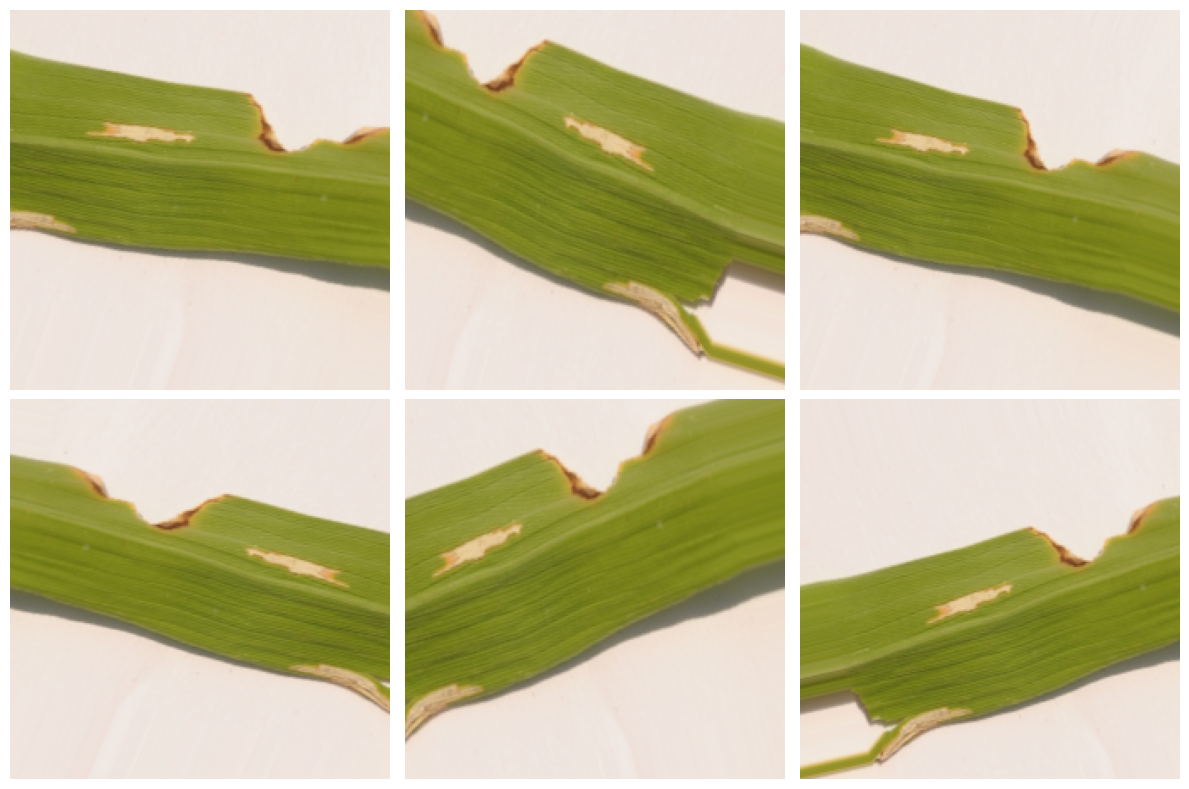

In [31]:
sample = X_train[0].reshape(1, 224, 224, 3)

plt.figure(figsize=(12, 8))

i = 0

for batch in train_datagen.flow(sample, batch_size=1):

    plt.subplot(2, 3, i + 1)
    plt.imshow(batch[0])
    plt.axis("off")

    i += 1

    if i == 6:
        break

plt.tight_layout()
plt.show()

# Step 9: Build CNN Architecture
- Sequential() – Creates a Sequential CNN model, where layers are added one after another.
- Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)) – Adds the first convolutional layer with 32 filters of size 3 × 3 and ReLU activation to extract basic features such as edges and textures from 224 × 224 RGB images.
- MaxPooling2D(pool_size=(2,2)) – Reduces the size of the feature maps by taking the maximum value from each 2 × 2 region, decreasing computation while preserving important features.
- Conv2D(64, (3,3), activation='relu') – Adds a second convolutional layer with 64 filters to learn more complex features and disease patterns.
- MaxPooling2D(pool_size=(2,2)) – Further reduces the feature map dimensions, improving computational efficiency.
- Flatten() – Converts the 2D feature maps into a 1D vector so they can be passed to the dense layers.
- Dense(128, activation='relu') – Adds a fully connected hidden layer with 128 neurons to learn high-level patterns for classification.
- Dropout(0.5) – Randomly drops 50% of the neurons during training to reduce overfitting and improve generalization.
- Dense(3, activation='softmax') – Adds the output layer with 3 neurons, one for each rice leaf disease class. The Softmax activation outputs the probability for each class.
- model.compile() – Configures the model for training.
- optimizer='adam' – Uses the Adam optimizer, which updates the model weights efficiently.
- loss='sparse_categorical_crossentropy' – Uses the appropriate loss function for multi-class classification with integer labels.
- metrics=['accuracy'] – Tracks the model's classification accuracy during training and evaluation.
- model.summary() – Displays the complete architecture of the CNN model, including layers, output shapes, and the number of trainable parameters..

##### Importance of CNN Model
- Builds the CNN architecture for extracting image features and classifying rice leaf diseases.
- Learns hierarchical features through convolutional layers.
- Reduces overfitting using Dropout.
- Uses Softmax to classify images into one of the three disease classes.
- Compiles the model with suitable optimizer, loss function, and evaluation metric before training.

In [32]:
model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Flatten())

model.add(Dense(128, activation='relu'))

model.add(Dropout(0.5))

model.add(Dense(3, activation='softmax'))

# Step 10: Compile the CNN Model
- Compiles the CNN model before starting the training process.
- Defines the optimizer, loss function, and evaluation metric for the model.
- Uses Adam optimizer to update model weights efficiently during training.
- Uses categorical cross-entropy loss function for multi-class classification problems.
- Uses accuracy as a metric to measure the model's performance.
- Helps the model learn and improve by reducing prediction errors during training.

##### Importance
- Prepares the CNN model for the training process.
- Controls how the model learns from the training data.
- Helps measure the model's classification performance.
- Improves the model's ability to correctly identify rice leaf disease classes.

In [33]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 222, 222, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 109, 109, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 54, 54, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 186624)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │      23,888,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 3)                   │             387 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 23,907,779 (91.20 MB)

 Trainable params: 23,907,779 (91.20 MB)

 Non-trainable params: 0 (0.00 B)

# Step 11: Train the CNN model

- model.fit() – Starts the training process by feeding the training data to the CNN model.
- train_datagen.flow(X_train, y_train, batch_size=32) – Generates batches of 32 augmented training images along with their labels using the ImageDataGenerator.
- X_train – Contains the training images used to train the model.
- y_train – Contains the corresponding labels for the training images.
- batch_size=32 – Processes 32 images at a time before updating the model weights, improving memory efficiency.
- epochs=100 – Trains the model for 100 complete iterations over the entire training dataset.
- validation_data=(X_test, y_test) – Uses the testing dataset to evaluate the model after each epoch, helping monitor its performance on unseen data.
- history = – Stores the training history, including training accuracy, validation accuracy, training loss, and validation loss, which can later be used to plot learning curves.
##### Importance

- Training the CNN model is an important step because it enables the model to learn different disease patterns from rice leaf images. During training, the model improves its ability to recognize features such as spots, texture changes, and color variations. It helps the model achieve better classification accuracy and make reliable predictions on new, unseen rice leaf images.

In [34]:
history = model.fit(
    train_datagen.flow(X_train, y_train, batch_size=32),
    epochs=100,
    validation_data=(X_test, y_test)
)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 21s 7s/step - accuracy: 0.2526 - loss: 9.1009 - val_accuracy: 0.3333 - val_loss: 7.5532
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 13s 4s/step - accuracy: 0.3368 - loss: 6.4376 - val_accuracy: 0.3333 - val_loss: 1.5731
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step - accuracy: 0.3474 - loss: 2.2360 - val_accuracy: 0.3333 - val_loss: 1.3460
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 10s 3s/step - accuracy: 0.4105 - loss: 1.1975 - val_accuracy: 0.3750 - val_loss: 1.0680
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.3684 - loss: 1.1461 - val_accuracy: 0.6250 - val_loss: 0.9571
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.3579 - loss: 1.0544 - val_accuracy: 0.3333 - val_loss: 0.9570
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.3474 - loss: 1.0649 - val_accuracy: 0.6250 - val_loss: 0.9246
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.3895 - loss: 1.0384 - val_accuracy: 0.6667 - val_loss: 0.9181
Epoc

## Step 11: Evaluate the Model

- Evaluates the trained CNN model using the test dataset.
- Measures how well the model performs on unseen rice leaf images.
- Calculates test loss to identify the prediction error of the model.
- Calculates test accuracy to measure the percentage of correctly classified images.
- Converts accuracy into percentage format for better understanding.
- Helps determine the final performance of the trained model.

##### Importance

- Evaluating the CNN model is important because it shows how accurately the model can classify new rice leaf images that were not used during training. It helps verify the model's effectiveness, identify performance issues, and ensure that the model can make reliable disease predictions in real-world conditions.

In [35]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Loss :", test_loss)
print("Test Accuracy :", test_accuracy)
print("Test Accuracy (%):", test_accuracy * 100)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 269ms/step - accuracy: 0.9167 - loss: 0.4965
Test Loss : 0.49652743339538574
Test Accuracy : 0.9166666865348816
Test Accuracy (%): 91.66666865348816


## Step 12: Visualize Training and Validation Accuracy

- Creates a graph to compare training accuracy and validation accuracy during model training.
- Displays how the model's accuracy changes across different epochs.
- Training accuracy shows how well the model learns from the training dataset.
- Validation accuracy shows how well the model performs on unseen validation data.
- Helps identify whether the model is learning properly or overfitting.
- The graph provides a clear understanding of model performance improvement over time.

##### Importance

- Visualizing training and validation accuracy helps analyze the learning behavior of the CNN model. It allows us to check whether the model is improving during training and whether it can generalize well to new images. A similar trend between training and validation accuracy indicates good model performance, while a large difference may indicate overfitting.


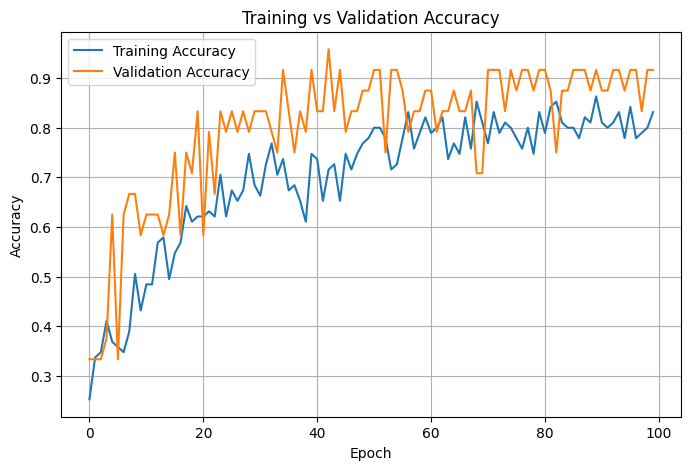

In [36]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

## *Plotting Training and Validation Loss*

- Helps monitor how the model's loss decreases during training.
- Compares training loss with validation loss to evaluate model performance.
- Indicates whether the model is learning effectively.
- Helps detect overfitting (training loss decreases while validation loss increases) or underfitting (both losses remain high).
- Assists in deciding whether to stop training or tune the model.

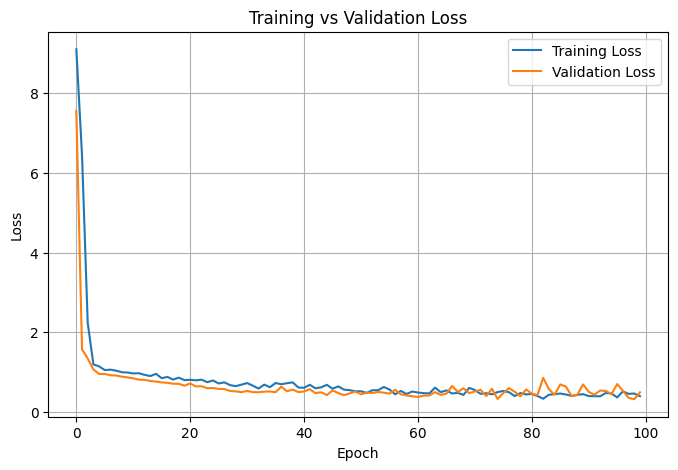

In [37]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

### *Predicting the Disease Class for Test Images*
- Converts the model's probability outputs into final class predictions.
- Assigns each test image to the disease class with the highest predicted probability.
- The predicted class labels are used to evaluate the model using metrics such as accuracy, confusion matrix, precision, recall, and F1-score.

In [38]:
# Predict probabilities
y_pred = model.predict(X_test)

# Convert probabilities to class labels
y_pred_classes = np.argmax(y_pred, axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 365ms/step


### *Generating and Visualizing the Confusion Matrix*
- Shows how well the CNN model classifies each disease.
- Displays the number of correct and incorrect predictions for every class.
- Helps identify which disease classes are being confused with one another.
- Provides deeper insight into model performance beyond overall accuracy.
- Forms the basis for calculating Precision, Recall, and F1-score.

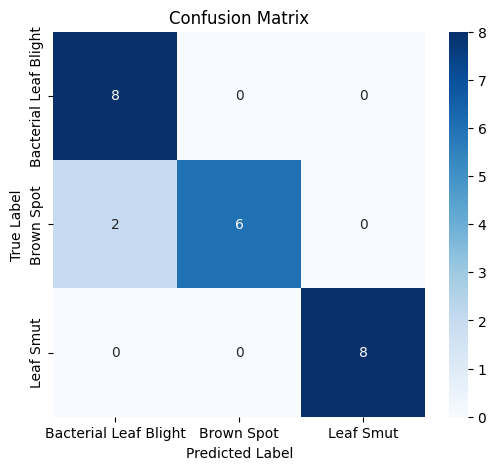

In [39]:
cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Bacterial Leaf Blight','Brown Spot','Leaf Smut'],
    yticklabels=['Bacterial Leaf Blight','Brown Spot','Leaf Smut']
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.show()

In [40]:
## Classification Report

In [41]:
print(classification_report(
    y_test,
    y_pred_classes,
    target_names=[
        'Bacterial Leaf Blight',
        'Brown Spot',
        'Leaf Smut'
    ]
))

                       precision    recall  f1-score   support

Bacterial Leaf Blight       0.80      1.00      0.89         8
           Brown Spot       1.00      0.75      0.86         8
            Leaf Smut       1.00      1.00      1.00         8

             accuracy                           0.92        24
            macro avg       0.93      0.92      0.92        24
         weighted avg       0.93      0.92      0.92        24



In [42]:
model.save("rice_leaf_disease_cnn.keras")

## *Challenges Faced* 

- Limited Dataset: The dataset contained a limited number of images, making it difficult for the CNN model to learn all disease variations effectively.
- Image Quality Variations: Differences in lighting conditions, backgrounds, camera angles, and image resolution affected the consistency of the input data.
- Similar Disease Symptoms: Some rice leaf diseases have visually similar symptoms, making it challenging for the model to distinguish between them accurately.
- Model Overfitting: Due to the small dataset and a large number of trainable parameters, the model showed signs of overfitting during training.
- Hyperparameter Tuning: Finding the optimal values for epochs, batch size, learning rate, and network architecture required multiple experiments.
- High Computational Cost: Training the CNN model on high-resolution images required significant processing time and computational resources.
- Prediction Bias: During testing, the model occasionally favored one class over others, requiring further tuning and dataset improvements to achieve balanced predictions.
- Data Augmentation Selection: Choosing appropriate augmentation techniques was important to increase data diversity without distorting disease characteristics.

## *Conclusion*

- Developed a Convolutional Neural Network (CNN)-based Rice Leaf Disease Detection system to classify three major rice leaf diseases: Bacterial Leaf Blight, Brown Spot, and Leaf Smut.
- Performed comprehensive data preprocessing, including image resizing, normalization, train-test splitting, and data augmentation to improve the quality and diversity of the training data.
- Designed and trained a CNN model capable of automatically extracting important features from leaf images and performing multi-class disease classification.
- Evaluated the model using accuracy, loss curves, and a confusion matrix, providing insights into its classification performance and areas for improvement.
- This project demonstrates how Deep Learning and Computer Vision can support early disease detection, enabling faster diagnosis and helping farmers make timely decisions to reduce crop losses.
- With a larger dataset, additional hyperparameter tuning, and advanced pre-trained models such as MobileNetV2, ResNet50, or EfficientNet, the system can achieve even higher accuracy and be deployed as a practical solution for real-world smart agriculture applications.